## 1. Import các thư viện cần thiết

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Kiểm tra GPU

In [13]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        print(gpu.name)
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No gpu devices found")
    

/physical_device:GPU:0
/physical_device:GPU:1


## 3. Cấu hình và đường dẫn dữ liệu

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 128
NUM_CLASSES = 5 

train_dir = '../DataSet/train'
valid_dir = '../DataSet/valid'
test_dir  = '../DataSet/test'

## 4. Tiền xử lý ảnh & tạo generator

In [16]:
train_datagen = ImageDataGenerator(rescale=1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse'
)

Found 25136 images belonging to 5 classes.
Found 2812 images belonging to 5 classes.
Found 1649 images belonging to 5 classes.


## 5. Tính class weights

In [18]:
train_labels = train_generator.classes
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = dict(enumerate(class_weights))

## 6. Xây dựng mô hình DenseNet201

In [ ]:
pretrained_model = DenseNet201(weights='imagenet', include_top=False, input_shape=[*IMG_SIZE, 3])
pretrained_model.trainable = True

inp = Input(shape=(*IMG_SIZE, 3))
densenet = pretrained_model(inp)

X = GlobalAveragePooling2D()(densenet)
X = Dense(256, activation='elu')(X)
X = Dropout(0.5)(X)

X = Dense(128, activation='elu')(X)
X = Dropout(0.3)(X)

X = Dense(32, activation='elu')(X)

out = Dense(NUM_CLASSES, activation='softmax')(X)

model = Model(inputs=inp, outputs=out)

my_callbacks = [
    EarlyStopping(
        min_delta=0.001, 
        monitor='val_loss', 
        patience=20, 
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.1, 
        patience=10
    ),
    ModelCheckpoint(
        filepath='../Model/best_model.keras', 
        monitor='val_loss', 
        save_best_only=True, 
        save_weights_only=False  
    )
]

model.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])


## 7. Huấn luyện mô hình

In [20]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=50,
    class_weight=class_weights,
    callbacks=my_callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 760s 2s/step - accuracy: 0.4467 - loss: 1.2459 - val_accuracy: 0.5068 - val_loss: 1.9888 - learning_rate: 0.0010
Epoch 2/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 128s 646ms/step - accuracy: 0.6140 - loss: 0.7290 - val_accuracy: 0.6931 - val_loss: 0.8877 - learning_rate: 0.0010
Epoch 3/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 126s 640ms/step - accuracy: 0.6638 - loss: 0.5963 - val_accuracy: 0.6472 - val_loss: 28.9263 - learning_rate: 0.0010
Epoch 4/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 127s 642ms/step - accuracy: 0.6693 - loss: 0.6000 - val_accuracy: 0.4762 - val_loss: 1.4597 - learning_rate: 0.0010
Epoch 5/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 133s 675ms/step - accuracy: 0.7062 - loss: 0.5138 - val_accuracy: 0.7048 - val_loss: 0.7391 - learning_rate: 0.0010
Epoch 6/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 130s 657ms/step - accuracy: 0.7389 - loss: 0.4441 - val_accuracy: 0.7336 - val_loss: 0.6911 - learning_rate: 0.0010
Epoch 7/50
197/197 ━━━━━━━━━━━━━━━━━━━━ 126s 640ms/step - accuracy

## 8. Đánh giá trên tập test

In [21]:
test_loss, test_acc= model.evaluate(test_generator)
print(f"Test loss: {test_loss:.2f}")
print(f"Test accuracy: {test_acc:.2f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.9293 - loss: 0.2845 
Test loss: 0.27
Test accuracy: 0.93


## 9. Biểu đồ Accuracy & Loss

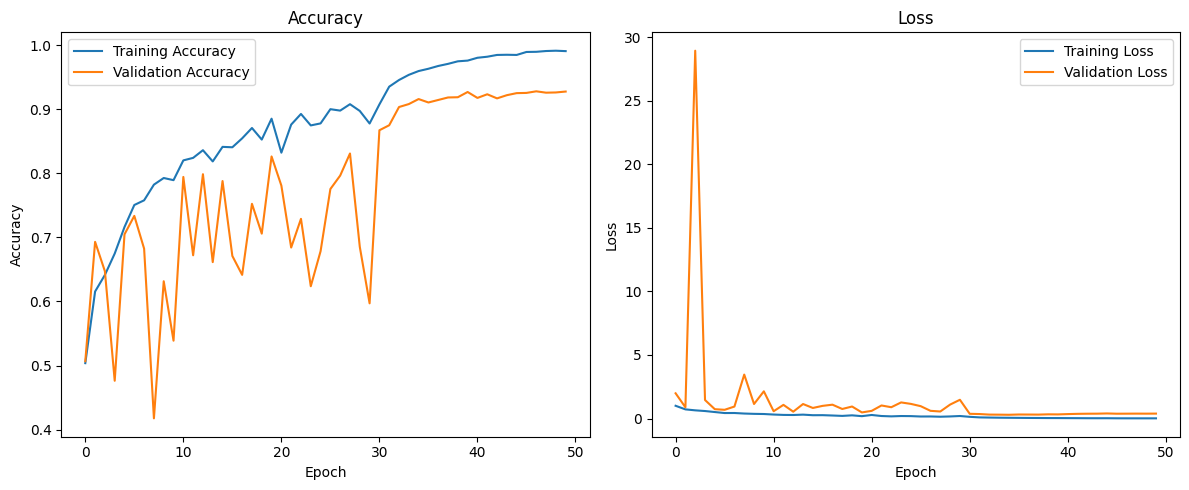

In [ ]:
history_dict = history.history

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_dict['accuracy'], label='Training Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history_dict['loss'], label='Training Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('../Results/Png/train_history.png', dpi=150)
plt.show()

## 10. biểu đồ ma trận nhầm lẫn 

In [25]:
def plot_confusion_matrix(cm, class_names, title='Confusion Matrix'):
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [30]:
def get_predictions_and_labels(generator):
    num_samples = generator.samples
    predictions = []
    labels = []
    generator.reset()
    
    steps = int(np.ceil(num_samples / generator.batch_size))
    
    for _ in range(steps):
        batch_images, batch_labels = next(generator)
        
        batch_predictions = model.predict(batch_images, verbose=0)
        
        batch_pred_labels = np.argmax(batch_predictions, axis=1)
        batch_true_labels = batch_labels
        
        predictions.extend(batch_pred_labels)
        labels.extend(batch_true_labels)
    
    return np.array(labels), np.array(predictions)

In [32]:
class_names = list(valid_generator.class_indices.keys())

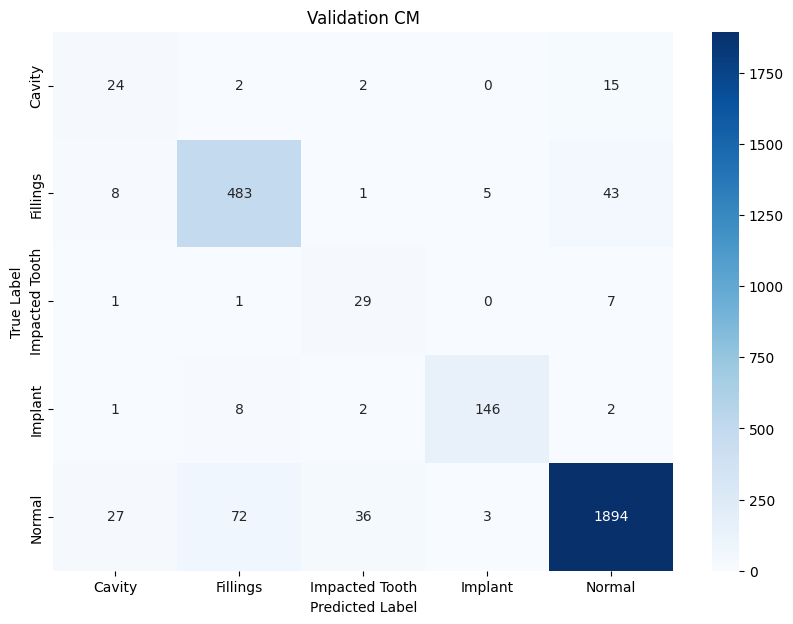

                precision    recall  f1-score   support

        Cavity       0.39      0.56      0.46        43
      Fillings       0.85      0.89      0.87       540
Impacted Tooth       0.41      0.76      0.54        38
       Implant       0.95      0.92      0.93       159
        Normal       0.97      0.93      0.95      2032

      accuracy                           0.92      2812
     macro avg       0.71      0.81      0.75      2812
  weighted avg       0.93      0.92      0.92      2812



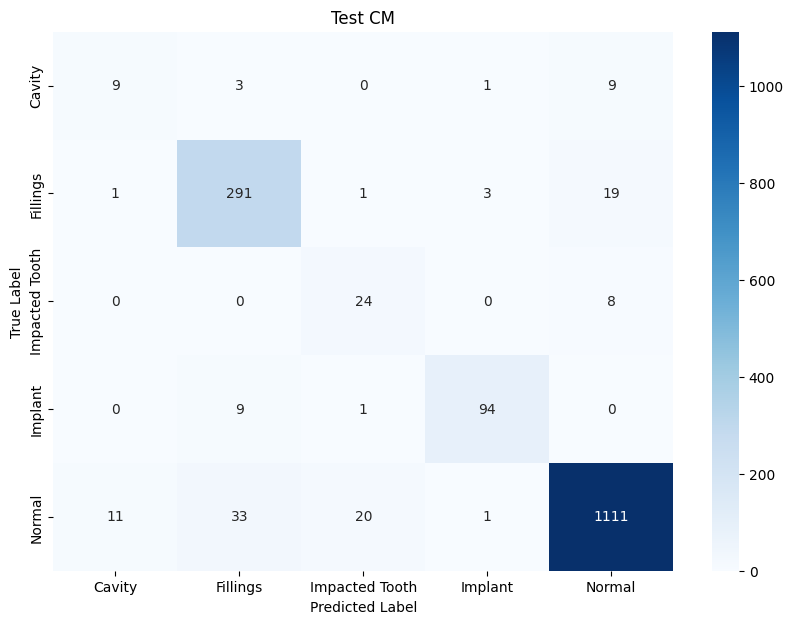

                precision    recall  f1-score   support

        Cavity       0.43      0.41      0.42        22
      Fillings       0.87      0.92      0.89       315
Impacted Tooth       0.52      0.75      0.62        32
       Implant       0.95      0.90      0.93       104
        Normal       0.97      0.94      0.96      1176

      accuracy                           0.93      1649
     macro avg       0.75      0.79      0.76      1649
  weighted avg       0.93      0.93      0.93      1649



In [33]:
y_true_val, y_pred_val = get_predictions_and_labels(valid_generator)

cm_val = confusion_matrix(y_true_val, y_pred_val)
plot_confusion_matrix(cm_val, class_names, title='Validation CM')
print(classification_report(y_true_val, y_pred_val, target_names=class_names))

y_true_test, y_pred_test = get_predictions_and_labels(test_generator)

cm_test = confusion_matrix(y_true_test, y_pred_test)
plot_confusion_matrix(cm_test, class_names, title='Test CM')
print(classification_report(y_true_test, y_pred_test, target_names=class_names))